# Baseball Win Probability — Experiment Comparison

Runs multiple logistic regression configurations and compares results side-by-side.  
Train: 2023–2024 seasons | Test: 2025 season

To add a new experiment, append a dict to `EXPERIMENTS` in the config cell and re-run.

In [24]:
from pathlib import Path

# ── Data ────────────────────────────────────────────────────────────────────
DATA_DIR      = Path("data")
TRAIN_PATH    = DATA_DIR / "train_features.parquet"
TEST_PATH     = DATA_DIR / "test_features.parquet"
METADATA_COLS = ["date", "home_team", "away_team", "home_win"]

RANDOM_SEED = 42

BEST_C = 0.23357214690901212  # from previous LogisticRegressionCV run

# ── Experiments ──────────────────────────────────────────────────────────────
# Each dict defines one full pipeline run. Keys:
#   name              : label shown in all plots and tables
#   use_differential  : True = 59 home-minus-away diff features; False = 118 raw features
#   use_scale         : True = StandardScaler before model (and before poly if enabled)
#   poly_degree       : None = no expansion; 2 = degree-2 polynomial features
#   poly_interaction  : True = interaction terms only (no x^2); ignored if poly_degree=None
#   model             : kwargs passed directly to sklearn LogisticRegression
EXPERIMENTS = [
    {
        "name":             "Baseline (diff, L2 C=1)",
        "use_differential": True,
        "use_scale":        False,
        "poly_degree":      None,
        "poly_interaction": True,
        "model": {"penalty": "l2", "C": BEST_C, "solver": "liblinear", "max_iter": 10000, "random_state": RANDOM_SEED},
    },
    # {
    #     "name":             "Poly interactions (diff, L2 C=0.01)",
    #     "use_differential": True,
    #     "use_scale":        False,
    #     "poly_degree":      2,
    #     "poly_interaction": True,
    #     "model": {"penalty": "l2", "C": 0.01, "max_iter": 10000, "random_state": RANDOM_SEED},
    # },
    {
        "name": "ElasticNet (diff, no poly)",
        "use_differential": True,
        "use_scale": True,          # required for elasticnet to work well
        "poly_degree": None,
        "poly_interaction": True,
        "model": {
            "penalty": "elasticnet",
            "solver": "saga",
            "C": BEST_C,
            "l1_ratio": 0.5,        # 0 = pure L2, 1 = pure L1; try 0.1, 0.5, 0.9
            "max_iter": 10000,
            "random_state": 42,
        },
    },
    {
        "name":             "L1 sparse (diff, no poly)",
        "use_differential": True,
        "use_scale":        False,
        "poly_degree":      None,
        "poly_interaction": True,
        "model": {"penalty": "l1", "C": BEST_C, "solver": "liblinear", "max_iter": 10000, "random_state": RANDOM_SEED},
    },
    {
        "name":             "No penalty (diff, no poly)",
        "use_differential": True,
        "use_scale":        False,
        "poly_degree":      None,
        "poly_interaction": True,
        "model": {"penalty": None, "C": BEST_C, "max_iter": 10000, "random_state": RANDOM_SEED},
    },
]

# ── Drill-down ───────────────────────────────────────────────────────────────
# Name of experiment to show detailed feature importance + calibration plots for
INSPECT_EXPERIMENT = "L1 sparse (diff, no poly)"

# ── Evaluation ───────────────────────────────────────────────────────────────
CALIBRATION_BINS = 10
TOP_N_FEATURES   = 20

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

sns.set_theme(style="whitegrid")

## 2. Load Data

In [3]:
train_df = pd.read_parquet(TRAIN_PATH)
test_df  = pd.read_parquet(TEST_PATH)

print(f"Train: {train_df.shape}  ({train_df['date'].dt.year.min()}-{train_df['date'].dt.year.max()})")
print(f"Test:  {test_df.shape}   ({test_df['date'].dt.year.min()}-{test_df['date'].dt.year.max()})")
print(f"\nTarget balance (train): {train_df['home_win'].mean():.3f} home win rate")
print(f"Target balance (test):  {test_df['home_win'].mean():.3f} home win rate")

feat_cols = [c for c in train_df.columns if c not in METADATA_COLS]
y_train   = train_df["home_win"].values
y_test    = test_df["home_win"].values

Train: (4859, 122)  (2023-2024)
Test:  (2430, 122)   (2025-2025)

Target balance (train): 0.521 home win rate
Target balance (test):  0.543 home win rate


## 3. Pipeline Helpers

In [ ]:
BATTING_STATS            = ["BA", "OBP", "SLG", "OPS", "K%", "BB%"]
PITCHING_STATS           = ["ERA", "WHIP", "SO9", "SO/W", "IP"]
PITCHING_LOWER_IS_BETTER = {"ERA", "WHIP"}

def run_logisitic_regressionCV():
    from sklearn.linear_model import LogisticRegressionCV

    X_train_arr = make_differential_features(train_df).values

    cv_model = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 20),   # 20 values from 0.001 to 100
        cv=5,
        penalty="l2",
        solver="lbfgs",
        max_iter=10000,
        random_state=42,
    )
    cv_model.fit(X_train_arr, y_train)
    print(f"Best C: {cv_model.C_[0]}")


def make_differential_features(df):
    """Return a DataFrame of home-minus-away differential features.

    Batting:  diff_bat{N}_{stat} = home_bat{N}_{stat} - away_bat{N}_{stat}
    Pitching: diff_sp_{stat}     = home_sp_{stat} - away_sp_{stat}   (SO9, SO/W, IP)
              diff_sp_{stat}     = away_sp_{stat} - home_sp_{stat}   (ERA, WHIP)
    All columns oriented so positive = home team advantage.
    """
    diffs = {}
    for n in range(1, 10):
        for stat in BATTING_STATS:
            diffs[f"diff_bat{n}_{stat}"] = df[f"home_bat{n}_{stat}"] - df[f"away_bat{n}_{stat}"]
    for stat in PITCHING_STATS:
        if stat in PITCHING_LOWER_IS_BETTER:
            diffs[f"diff_sp_{stat}"] = df[f"away_sp_{stat}"] - df[f"home_sp_{stat}"]
        else:
            diffs[f"diff_sp_{stat}"] = df[f"home_sp_{stat}"] - df[f"away_sp_{stat}"]
    return pd.DataFrame(diffs, index=df.index)


def run_experiment(cfg, train_df, test_df, feat_cols, y_train, y_test):
    """Run one full pipeline (features → preprocessing → train → evaluate).

    Returns a dict with metrics, predictions, model, and feature names
    needed for downstream plots.
    """
    # --- Feature engineering ---
    if cfg["use_differential"]:
        X_tr = make_differential_features(train_df)
        X_te = make_differential_features(test_df)
    else:
        X_tr = train_df[feat_cols].copy()
        X_te = test_df[feat_cols].copy()

    assert X_tr.isna().sum().sum() == 0
    assert X_te.isna().sum().sum() == 0

    base_feature_names = list(X_tr.columns)

    # --- Preprocessing ---
    if cfg["use_scale"]:
        scaler = StandardScaler()
        X_tr_arr = scaler.fit_transform(X_tr)
        X_te_arr = scaler.transform(X_te)
    else:
        X_tr_arr = X_tr.values
        X_te_arr = X_te.values

    feature_names = base_feature_names

    if cfg["poly_degree"] is not None:
        poly = PolynomialFeatures(
            degree=cfg["poly_degree"],
            interaction_only=cfg["poly_interaction"],
            include_bias=False,
        )
        X_tr_arr = poly.fit_transform(X_tr_arr)
        X_te_arr = poly.transform(X_te_arr)
        feature_names = poly.get_feature_names_out(base_feature_names).tolist()

    # --- Train ---
    model = LogisticRegression(**cfg["model"])
    model.fit(X_tr_arr, y_train)

    if model.n_iter_[0] == cfg["model"].get("max_iter", 100):
        print(f"  WARNING [{cfg['name']}]: max_iter reached ({model.n_iter_[0]})")

    # --- Evaluate ---
    y_pred_tr = model.predict(X_tr_arr)
    y_pred_te = model.predict(X_te_arr)
    y_prob_tr = model.predict_proba(X_tr_arr)[:, 1]
    y_prob_te = model.predict_proba(X_te_arr)[:, 1]

    return {
        "name":          cfg["name"],
        "model":         model,
        "feature_names": feature_names,
        "y_test":        y_test,
        "y_pred_test":   y_pred_te,
        "y_prob_train":  y_prob_tr,
        "y_prob_test":   y_prob_te,
        "train_acc":     accuracy_score(y_train, y_pred_tr),
        "test_acc":      accuracy_score(y_test,  y_pred_te),
        "train_auc":     roc_auc_score(y_train,  y_prob_tr),
        "test_auc":      roc_auc_score(y_test,   y_prob_te),
        "n_iter":        model.n_iter_[0],
        "n_features":    X_tr_arr.shape[1],
    }

## 4. Run All Experiments

In [25]:
results = []
for cfg in EXPERIMENTS:
    print(f"Running: {cfg['name']} ...", end=" ")
    r = run_experiment(cfg, train_df, test_df, feat_cols, y_train, y_test)
    results.append(r)
    print(f"done  (test acc={r['test_acc']:.4f}, auc={r['test_auc']:.4f}, {r['n_features']} features, {r['n_iter']} iters)")

print(f"\nFinished {len(results)} experiments.")

Running: Baseline (diff, L2 C=1) ... done  (test acc=0.5909, auc=0.6283, 59 features, 16 iters)
Running: ElasticNet (diff, no poly) ... 

/Users/kaitlynoikle/cs-projects/ml-final-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/kaitlynoikle/cs-projects/ml-final-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


done  (test acc=0.5835, auc=0.6233, 59 features, 381 iters)
Running: L1 sparse (diff, no poly) ... done  (test acc=0.5881, auc=0.6287, 59 features, 14 iters)
Running: No penalty (diff, no poly) ... 

/Users/kaitlynoikle/cs-projects/ml-final-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/kaitlynoikle/cs-projects/ml-final-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/kaitlynoikle/cs-projects/ml-final-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. U

done  (test acc=0.5840, auc=0.6225, 59 features, 1969 iters)

Finished 4 experiments.


## 5. Comparison Table

In [27]:
summary = pd.DataFrame([{
    "Experiment":   r["name"],
    "Features":     r["n_features"],
    "Iters":        r["n_iter"],
    "Train Acc":    r["train_acc"],
    "Test Acc":     r["test_acc"],
    "Train AUC":    r["train_auc"],
    "Test AUC":     r["test_auc"],
} for r in results]).set_index("Experiment")

float_cols = [c for c in summary.columns if summary[c].dtype == float]
(
    summary.style
    .highlight_max(subset=["Test Acc", "Test AUC"], color="#c6efce")
    .highlight_max(subset=["Train Acc", "Train AUC"], color="#ffeb9c")
    .format("{:.4f}", subset=float_cols)
    .format("{:,}",   subset=["Features", "Iters"])
)

,Features,Iters,Train Acc,Test Acc,Train AUC,Test AUC
Experiment,,,,,,
"Baseline (diff, L2 C=1)",59,16,0.6053,0.5909,0.6440,0.6283
"ElasticNet (diff, no poly)",59,381,0.6067,0.5835,0.6474,0.6233
"L1 sparse (diff, no poly)",59,14,0.6063,0.5881,0.6415,0.6287
"No penalty (diff, no poly)",59,"1,969",0.6067,0.5840,0.6477,0.6225


## 6. Overlaid ROC Curves

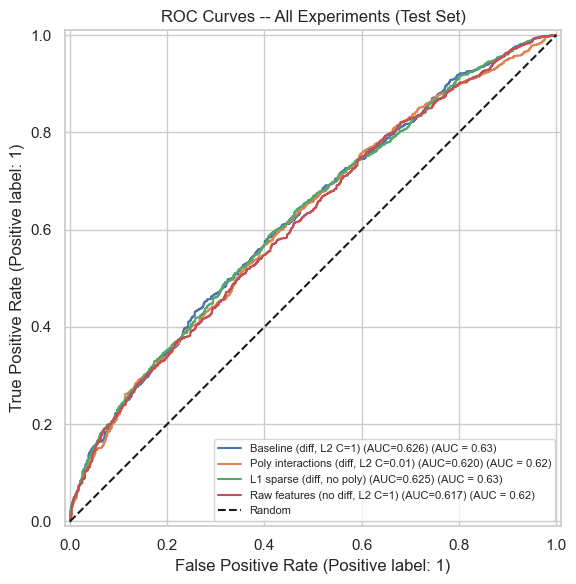

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
for r in results:
    RocCurveDisplay.from_predictions(
        r["y_test"], r["y_prob_test"],
        name=f"{r['name']} (AUC={r['test_auc']:.3f})",
        ax=ax,
    )
ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_title("ROC Curves -- All Experiments (Test Set)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 7. Metric Bar Charts

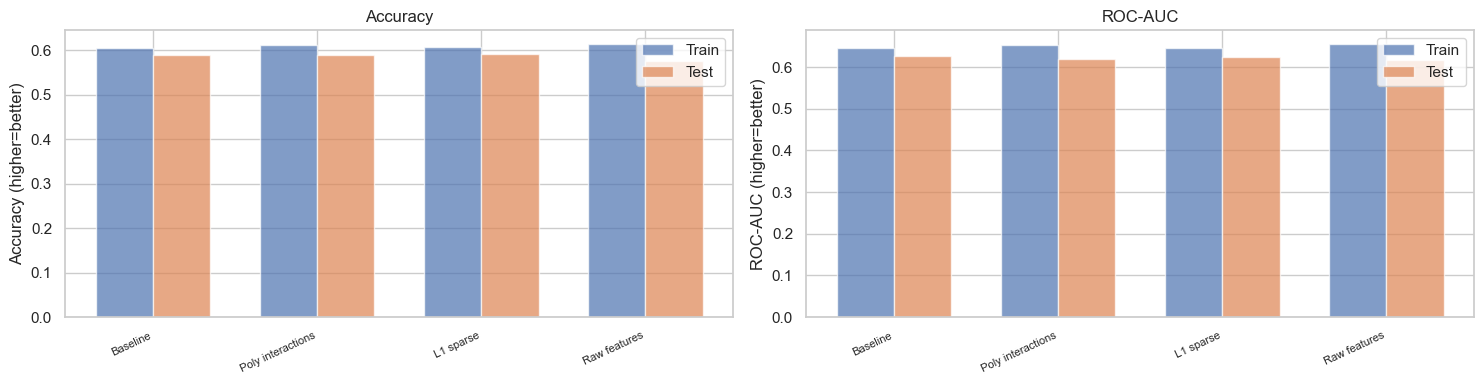

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
names = [r["name"] for r in results]
short_names = [n.split("(")[0].strip() for n in names]  # trim long labels

for ax, (train_key, test_key, title, lower_better) in zip(axes, [
    ("train_acc",   "test_acc",   "Accuracy",    False),
    ("train_auc",   "test_auc",   "ROC-AUC",     False),
]):
    x   = range(len(results))
    bar_w = 0.35
    ax.bar([i - bar_w/2 for i in x], [r[train_key] for r in results], bar_w, label="Train", alpha=0.7)
    ax.bar([i + bar_w/2 for i in x], [r[test_key]  for r in results], bar_w, label="Test",  alpha=0.7)
    ax.set_xticks(list(x))
    ax.set_xticklabels(short_names, rotation=25, ha="right", fontsize=8)
    ax.set_title(title)
    note = "(lower=better)" if lower_better else "(higher=better)"
    ax.set_ylabel(f"{title} {note}")
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Drill-down: Feature Importance

Showing detailed plots for the experiment named in `INSPECT_EXPERIMENT`.

Inspecting: L1 sparse (diff, no poly)
  59 features | 15 iterations
  Test Acc=0.5909  AUC=0.6252 


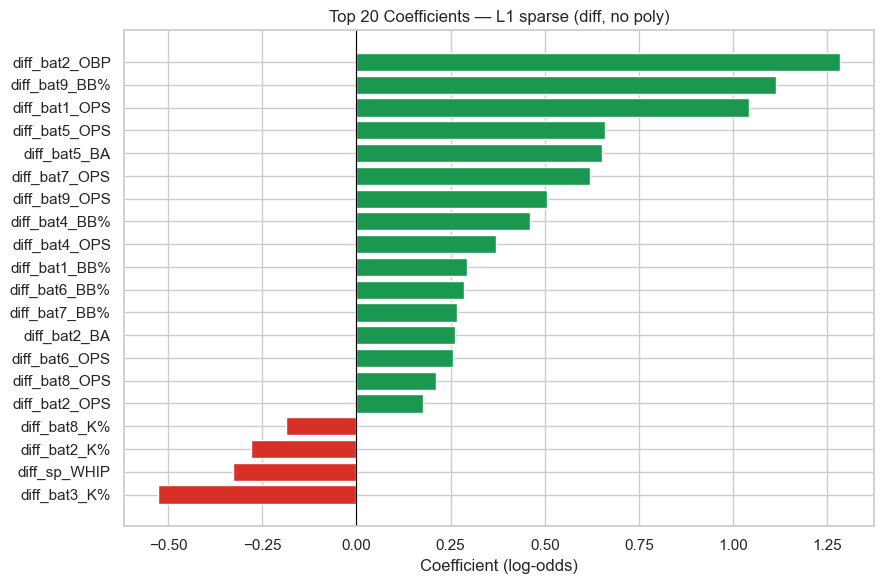


Top 10 features by absolute coefficient:
      feature  coefficient
diff_bat1_BB%     0.293694
diff_bat4_OPS     0.370190
diff_bat4_BB%     0.460496
diff_bat9_OPS     0.506650
diff_bat7_OPS     0.620230
 diff_bat5_BA     0.650914
diff_bat5_OPS     0.658624
diff_bat1_OPS     1.041447
diff_bat9_BB%     1.113793
diff_bat2_OBP     1.283652


In [10]:
r = next((x for x in results if x["name"] == INSPECT_EXPERIMENT), None)
if r is None:
    raise ValueError(f"No experiment named {INSPECT_EXPERIMENT!r}. Check INSPECT_EXPERIMENT in the config cell.")

print(f"Inspecting: {r['name']}")
print(f"  {r['n_features']} features | {r['n_iter']} iterations")
print(f"  Test Acc={r['test_acc']:.4f}  AUC={r['test_auc']:.4f} ")

coefs = r["model"].coef_[0]
coef_df = (
    pd.DataFrame({"feature": r["feature_names"], "coefficient": coefs})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .head(TOP_N_FEATURES)
    .sort_values("coefficient")
)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#d73027" if c < 0 else "#1a9850" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (log-odds)")
ax.set_title(f"Top {TOP_N_FEATURES} Coefficients — {r['name']}")
plt.tight_layout()
plt.show()

print(f"\nTop 10 features by absolute coefficient:")
print(coef_df.tail(10)[["feature", "coefficient"]].to_string(index=False))

## 9. Drill-down: Confusion Matrix & Classification Report

=== Classification Report — L1 sparse (diff, no poly) (Test) ===
              precision    recall  f1-score   support

    Away Win       0.56      0.51      0.54      1111
    Home Win       0.62      0.66      0.63      1319

    accuracy                           0.59      2430
   macro avg       0.59      0.58      0.58      2430
weighted avg       0.59      0.59      0.59      2430



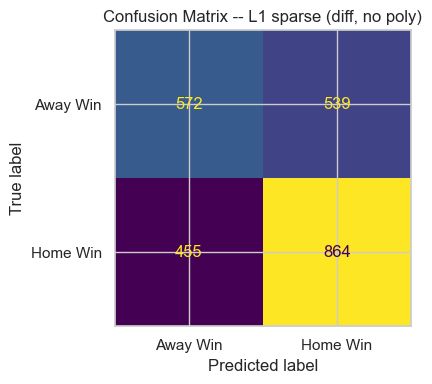

In [11]:
print(f"=== Classification Report — {r['name']} (Test) ===")
print(classification_report(r["y_test"], r["y_pred_test"], target_names=["Away Win", "Home Win"]))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(r["y_test"], r["y_pred_test"])
ConfusionMatrixDisplay(cm, display_labels=["Away Win", "Home Win"]).plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix -- {r['name']}")
plt.tight_layout()
plt.show()

---

## 10. Neural Network (PyTorch MLP)

Trains a multi-layer perceptron on the same differential features used by the best logistic regression runs. Three architectures (small / medium / large) are compared against each other and against the logistic regression baselines in the final table below.

In [17]:
import torch
import torch.nn as nn
import torch.utils.data as tud

In [18]:
class GameDataset(tud.Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.float32))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class WinProbMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], dropout: float):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def train_nn(model, X_tr, y_tr, epochs=100, batch_size=128, lr=1e-3, seed=42):
    torch.manual_seed(seed)
    loader = tud.DataLoader(GameDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y_batch)
        if epoch % 20 == 0 or epoch == 1:
            print(f"  epoch {epoch:>4d}/{epochs}  loss={total_loss / len(y_tr):.4f}")
    return model


def run_nn_experiment(cfg, train_df, test_df, feat_cols, y_train, y_test):
    """Run one full NN pipeline (differential features → scale → MLP → evaluate).

    Returns a metrics dict compatible with the logistic regression results list.
    """
    X_tr = make_differential_features(train_df).values.astype(np.float32)
    X_te = make_differential_features(test_df).values.astype(np.float32)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)

    torch.manual_seed(RANDOM_SEED)
    model = WinProbMLP(
        input_dim=X_tr.shape[1],
        hidden_dims=cfg["hidden_dims"],
        dropout=cfg["dropout"],
    )
    print(f"Running: {cfg['name']} ...")
    train_nn(model, X_tr, y_train, epochs=cfg["epochs"])

    model.eval()
    with torch.no_grad():
        logits_tr = model(torch.from_numpy(X_tr)).numpy()
        logits_te = model(torch.from_numpy(X_te)).numpy()

    y_prob_tr = torch.sigmoid(torch.tensor(logits_tr)).numpy()
    y_prob_te = torch.sigmoid(torch.tensor(logits_te)).numpy()
    y_pred_te = (y_prob_te >= 0.5).astype(int)

    test_acc = accuracy_score(y_test, y_pred_te)
    test_auc = roc_auc_score(y_test, y_prob_te)
    print(f"  → test acc={test_acc:.4f}  auc={test_auc:.4f}\n")

    return {
        "name":         cfg["name"],
        "y_test":       y_test,
        "y_pred_test":  y_pred_te,
        "y_prob_train": y_prob_tr,
        "y_prob_test":  y_prob_te,
        "train_acc":    accuracy_score(y_train, (y_prob_tr >= 0.5).astype(int)),
        "test_acc":     test_acc,
        "train_auc":    roc_auc_score(y_train, y_prob_tr),
        "test_auc":     test_auc,
        "n_features":   X_tr.shape[1],
    }

In [ ]:
# ── NN Experiment Configs ─────────────────────────────────────────────────────
# hidden_dims : list of layer widths (input → first hidden → ... → output)
# dropout     : dropout probability applied after each hidden layer
# epochs      : number of full passes over the training set
NN_EXPERIMENTS = [
    {
        "name":        "NN small (64-32)",
        "hidden_dims": [64, 32],
        "dropout":     0.2,
        "epochs":      100,
    },
    {
        "name":        "NN medium (128-64-32)",
        "hidden_dims": [128, 64, 32],
        "dropout":     0.2,
        "epochs":      150,
    },
    {
        "name":        "NN large (256-128-64)",
        "hidden_dims": [256, 128, 64],
        "dropout":     0.2,
        "epochs":      200,
    },
]

In [22]:
nn_results = []
for cfg in NN_EXPERIMENTS:
    r = run_nn_experiment(cfg, train_df, test_df, feat_cols, y_train, y_test)
    nn_results.append(r)

print(f"Finished {len(nn_results)} NN experiments.")

Running: NN small (64-32) ...
  epoch    1/100  loss=0.6838
  epoch   20/100  loss=0.6198
  epoch   40/100  loss=0.5748
  epoch   60/100  loss=0.5408
  epoch   80/100  loss=0.5232
  epoch  100/100  loss=0.4957
  → test acc=0.5749  auc=0.5859

Running: NN medium (128-64-32) ...
  epoch    1/150  loss=0.6831
  epoch   20/150  loss=0.5718
  epoch   40/150  loss=0.4594
  epoch   60/150  loss=0.3875
  epoch   80/150  loss=0.3402
  epoch  100/150  loss=0.2918
  epoch  120/150  loss=0.2771
  epoch  140/150  loss=0.2555
  → test acc=0.5506  auc=0.5709

Running: NN large (256-128-64) ...
  epoch    1/200  loss=0.6796
  epoch   20/200  loss=0.3284
  epoch   40/200  loss=0.1249
  epoch   60/200  loss=0.0932
  epoch   80/200  loss=0.0635
  epoch  100/200  loss=0.0575
  epoch  120/200  loss=0.0597
  epoch  140/200  loss=0.0464
  epoch  160/200  loss=0.0422
  epoch  180/200  loss=0.0363
  epoch  200/200  loss=0.0370
  → test acc=0.5284  auc=0.5392

Finished 3 NN experiments.


## 11. Full Comparison: Logistic Regression vs. Neural Network

In [23]:
def _to_row(r, model_type):
    return {
        "Model Type":  model_type,
        "Experiment":  r["name"],
        "Train Acc":   r["train_acc"],
        "Test Acc":    r["test_acc"],
        "Train AUC":   r["train_auc"],
        "Test AUC":    r["test_auc"],
    }

all_rows = (
    [_to_row(r, "Logistic Regression") for r in results]
    + [_to_row(r, "Neural Network")     for r in nn_results]
)
full_summary = pd.DataFrame(all_rows).set_index("Experiment")

float_cols = [c for c in full_summary.columns if full_summary[c].dtype == float]
(
    full_summary.style
    .highlight_max(subset=["Test Acc", "Test AUC"], color="#c6efce")
    .highlight_max(subset=["Train Acc", "Train AUC"], color="#ffeb9c")
    .format("{:.4f}", subset=float_cols)
)

,Model Type,Train Acc,Test Acc,Train AUC,Test AUC
Experiment,,,,,
"Baseline (diff, L2 C=1)",Logistic Regression,0.6053,0.5885,0.6453,0.6261
"Poly interactions (diff, L2 C=0.01)",Logistic Regression,0.6106,0.5889,0.6537,0.6200
"L1 sparse (diff, no poly)",Logistic Regression,0.6063,0.5909,0.6447,0.6252
"Raw features (no diff, L2 C=1)",Logistic Regression,0.6139,0.5765,0.6555,0.6169
NN small (64-32),Neural Network,0.8372,0.5749,0.9203,0.5859
NN medium (128-64-32),Neural Network,0.9953,0.5506,0.9998,0.5709
NN large (256-128-64),Neural Network,0.9998,0.5284,1.0000,0.5392


/Users/kaitlynoikle/cs-projects/ml-final-project/.venv/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/kaitlynoikle/cs-projects/ml-final-project/.venv/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/kaitlynoikle/cs-projects/ml-final-project/.venv/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/kaitlynoikle/cs-projects/ml-final-project/.venv/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in

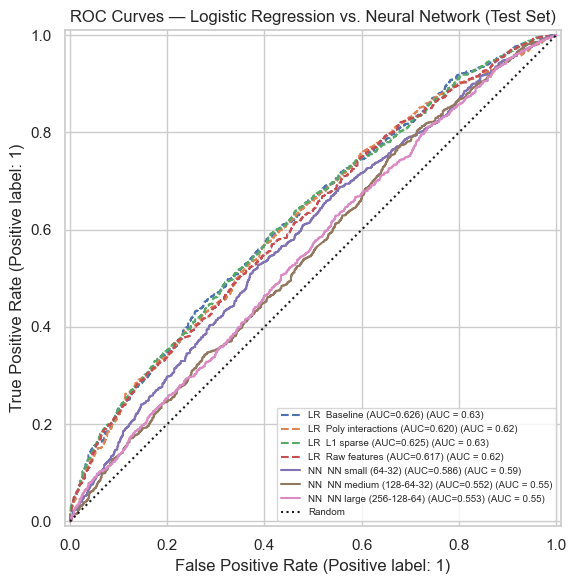

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
for r in results:
    RocCurveDisplay.from_predictions(
        r["y_test"], r["y_prob_test"],
        name=f"LR  {r['name'].split('(')[0].strip()} (AUC={r['test_auc']:.3f})",
        ax=ax, linestyle="--",
    )
for r in nn_results:
    RocCurveDisplay.from_predictions(
        r["y_test"], r["y_prob_test"],
        name=f"NN  {r['name']} (AUC={r['test_auc']:.3f})",
        ax=ax,
    )
ax.plot([0, 1], [0, 1], "k:", label="Random")
ax.set_title("ROC Curves — Logistic Regression vs. Neural Network (Test Set)")
ax.legend(loc="lower right", fontsize=7)
plt.tight_layout()
plt.show()